# Tema 3 — Aplicaciones de Redes Neuronales Convolucionales en Visión

**Curso:** PFAD-PADCC-VIC04 · Visión por Computadora  
**Institución:** TecNM Virtual · 2025  
**Actividad:** T3.A3.1 — Implementación de clasificación y rastreo de objetos con RNC

---

## ¿Qué haremos en este notebook?

Integraremos los conocimientos de los Temas 1 y 2 dentro de una arquitectura
completa de CNN para:

1. **Clasificar imágenes** de CIFAR-10 (3 clases) usando una CNN.
2. **Rastrear objetos** en una secuencia de imágenes usando un tracker por centroide.
3. **Evaluar** el desempeño con métricas objetivas (accuracy, matriz de confusión).
4. **Reflexionar** sobre la conexión entre los filtros aprendidos y los filtros del Tema 2.

---

### Estructura del notebook

| Paso | Contenido |
|------|-----------|
| **Configuración** | Parámetros globales del modelo |
| **Paso 1** | Selección del problema y contexto |
| **Paso 2** | Verificación del entorno |
| **Paso 3** | Carga y visualización de CIFAR-10 |
| **Paso 4** | Modelo CNN: arquitectura, entrenamiento y evaluación |
| **Paso 5** | Rastreo de objetos (Centroide Tracker) |
| **Paso 6** | Análisis de resultados y reflexión |
| **Paso 7** | Instrucciones para el reporte final |

> **Instrucción clave:** Busca las celdas marcadas con `### ✏️ COMPLETAR` y rellena
> el código o texto donde se indique. Las celdas ya funcionales no necesitan modificación.


Se utiliza **CIFAR-10**, uno de los benchmarks más usados en visión por computadora.
Contiene 60 000 imágenes RGB de 32×32 píxeles distribuidas en **10 clases**.

Para adaptar el notebook a tu contexto de aplicación, elige entre **2 y 10 clases**
de la siguiente tabla y actualiza las variables `CLASES` y `CLASES_CIFAR` en la
celda de **Configuración Global** al inicio del notebook.

| Clase | Índice CIFAR-10 | Ejemplos |
|-------|:--------------:|----------|
| Avión | 0 | aeronaves comerciales y militares desde distintos ángulos |
| Automóvil | 1 | autos, camionetas y vehículos de pasajeros |
| Pájaro | 2 | aves en vuelo y posadas |
| Gato | 3 | gatos domésticos en diversas posturas |
| Ciervo | 4 | venados y cérvidos en entornos naturales |
| Perro | 5 | perros domésticos de distintas razas |
| Rana | 6 | anfibios en entornos acuáticos y terrestres |
| Caballo | 7 | caballos en movimiento y en reposo |
| Barco | 8 | embarcaciones marítimas y fluviales |
| Camión | 9 | camiones de carga, volteo y transporte pesado |

> **Ejemplo — Contexto de tráfico urbano** (3 clases):
> ```python
> CLASES       = ["auto", "camion", "barco"]
> CLASES_CIFAR = [1, 9, 8]
> ```

> **Ejemplo — Contexto de fauna silvestre** (4 clases):
> ```python
> CLASES       = ["pajaro", "ciervo", "caballo", "rana"]
> CLASES_CIFAR = [2, 4, 7, 6]
> ```

> **Nota:** La primera ejecución descarga CIFAR-10 (~170 MB) y lo almacena en caché
> local. Las ejecuciones siguientes usan la caché y no requieren internet.

In [1]:
# =============================================================
# CONFIGURACIÓN GLOBAL
# =============================================================

# ── Parámetros del modelo ──────────────────────────────────────
# CIFAR-10 usa 3 clases para mantener tiempos de entrenamiento
# razonables en CPU: avión (0), automóvil (1), pájaro (2)
CLASES        = ["avion", "auto", "pajaro"]
CLASES_CIFAR  = [0, 1, 2]           # índices originales en CIFAR-10
IMG_SIZE      = 32                  # tamaño de entrada a la CNN
EPOCAS        = 10                  # épocas máximas de entrenamiento
BATCH_SIZE    = 32                  # imágenes por lote
LEARNING_RATE = 0.001               # tasa de aprendizaje inicial

# ── Semilla aleatoria para reproducibilidad ────────────────────
import random, numpy as np, os
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"   # silencia logs de TF
os.environ["PYTHONHASHSEED"]        = str(SEED)

print("[Config] Clases CIFAR-10 :", CLASES)
print(f"[Config] IMG_SIZE        : {IMG_SIZE}x{IMG_SIZE}")
print(f"[Config] Épocas          : {EPOCAS}  |  Batch: {BATCH_SIZE}  |  LR: {LEARNING_RATE}")


[Config] Clases CIFAR-10 : ['avion', 'auto', 'pajaro']
[Config] IMG_SIZE        : 32x32
[Config] Épocas          : 10  |  Batch: 32  |  LR: 0.001


---
## Paso 1 — Selección del Problema y Contexto

Antes de escribir código, define claramente **qué problema vas a resolver**.

Responde las preguntas de la siguiente celda Markdown.

### ✏️ COMPLETAR — Descripción del problema

**Contexto de aplicación:**  
> *Ejemplo: Industrial / Tráfico / Educativo / Médico / Otro*  
> *(Escribe aquí tu contexto)*

**Objetos a clasificar:**  
> *Ejemplo: piezas correctas vs. defectuosas (2 clases) | formas geométricas (3 clases)*  
> *(Escribe aquí)*

**Objetos a rastrear:**  
> *Ejemplo: peatones en video de cámara fija | objetos en banda transportadora*  
> *(Escribe aquí)*

**Propósito práctico (5–8 líneas):**  
> *¿Para qué serviría esta aplicación en la práctica?*  
> *(Escribe aquí tu párrafo descriptivo)*

**Tipo de imágenes o video:**  
> *Ejemplo: fotografías RGB 32x32, video MP4 30 fps, secuencia de cuadros PNG*  
> *(Escribe aquí)*

---
## Paso 2 — Verificación del Entorno de Trabajo

Importamos todas las bibliotecas necesarias y verificamos versiones.
Si alguna importación falla, ejecuta `pip install -r requirements.txt`.

In [2]:
# =============================================================
# PASO 2 — IMPORTACIONES Y VERIFICACIÓN DE VERSIONES
# =============================================================

# ── Bibliotecas estándar ───────────────────────────────────────
import os
import random
import warnings
warnings.filterwarnings("ignore")

# ── Núcleo numérico ────────────────────────────────────────────
import numpy as np

# ── Visualización ─────────────────────────────────────────────
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── Visión computacional ───────────────────────────────────────
import cv2

# ── Deep Learning ─────────────────────────────────────────────
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical

# ── Métricas ──────────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)
import sklearn

# ── Herramientas adicionales ───────────────────────────────────
from collections import OrderedDict
from scipy.spatial import distance as dist   # para distancia euclidiana en tracker

# ── Reporte de versiones ───────────────────────────────────────
print("=" * 50)
print(" Verificación de entorno — Tema 3")
print("=" * 50)
print(f" numpy       : {np.__version__}")
print(f" matplotlib  : {matplotlib.__version__}")
print(f" opencv      : {cv2.__version__}")
print(f" tensorflow  : {tf.__version__}")
print(f" scikit-learn: {sklearn.__version__}")
print(f" GPU visible : {len(tf.config.list_physical_devices('GPU')) > 0}")
print("=" * 50)
print(" ✅ Todas las bibliotecas importadas correctamente")
print("=" * 50)


 Verificación de entorno — Tema 3
 numpy       : 1.26.4
 matplotlib  : 3.10.9
 opencv      : 4.11.0
 tensorflow  : 2.15.0
 scikit-learn: 1.7.2
 GPU visible : False
 ✅ Todas las bibliotecas importadas correctamente


---
## Paso 3 — Dataset: Carga y Visualización

Se utiliza **CIFAR-10**, uno de los benchmarks más usados en visión por computadora.
Contiene 60 000 imágenes RGB de 32×32 píxeles en 10 clases.
Para mantener tiempos de entrenamiento razonables en CPU, trabajamos con
**3 clases**: avión, automóvil y pájaro.

| Clase | Índice CIFAR-10 | Ejemplos |
|-------|:--------------:|----------|
| Avión | 0 | fotografías de aviones desde distintos ángulos |
| Automóvil | 1 | autos, camionetas, vehículos de pasajeros |
| Pájaro | 2 | aves en vuelo y posadas |

> **Conexión con Tema 1:** El preprocesamiento que realizamos aquí (normalización a [0, 1])
> es exactamente lo que se vio en adquisición y representación de imágenes digitales.

> **Nota:** La primera ejecución descarga CIFAR-10 (~170 MB) y lo almacena en caché
> local. Las ejecuciones siguientes usan la caché y no requieren internet.


In [3]:
# =============================================================
# PASO 3A — CARGA Y PREPROCESAMIENTO DE CIFAR-10
# =============================================================

import tensorflow as tf

def cargar_cifar10_clases(clases_idx=(0, 1, 2), nombres=("avion", "auto", "pajaro")):
    """
    Carga CIFAR-10 y filtra las clases indicadas por su índice original.

    Clases CIFAR-10:
        0=avión  1=automóvil  2=pájaro   3=gato     4=ciervo
        5=perro  6=rana       7=caballo  8=barco    9=camión

    Preprocesamiento aplicado (Tema 1):
        - Normalización de píxeles: [0, 255] → [0.0, 1.0]
        - Re-etiquetado: índices originales → 0, 1, 2 (consecutivos)

    Retorna
    -------
    (X_train, y_train), (X_val, y_val), (X_test, y_test)
    Todas las imágenes float32 en [0, 1].
    """
    print("[Dataset] Cargando CIFAR-10...")
    (X_tr, y_tr), (X_te, y_te) = tf.keras.datasets.cifar10.load_data()
    y_tr = y_tr.flatten()
    y_te = y_te.flatten()

    def _filtrar(X, y):
        mask = [i for i, label in enumerate(y) if label in clases_idx]
        X_f  = X[mask].astype("float32") / 255.0   # normalizar
        # Re-etiquetar 0,1,2 en lugar de los índices originales
        y_f  = [list(clases_idx).index(y[i]) for i in mask]
        return X_f, np.array(y_f, dtype=np.int64)

    X_train_f, y_train_f = _filtrar(X_tr, y_tr)
    X_todo_t,  y_todo_t  = _filtrar(X_te, y_te)

    # Partir el test original 50/50 → validación / prueba
    mid = len(X_todo_t) // 2
    return (
        (X_train_f,      y_train_f),
        (X_todo_t[:mid], y_todo_t[:mid]),
        (X_todo_t[mid:], y_todo_t[mid:])
    )


# ── Cargar el dataset ──────────────────────────────────────────
(X_train, y_train), (X_val, y_val), (X_test, y_test) = cargar_cifar10_clases(
    clases_idx = CLASES_CIFAR,
    nombres    = CLASES
)
nombres_clases = CLASES
N_CLASES       = len(nombres_clases)

print(f"[Dataset] Clases        : {nombres_clases}")
print(f"[Dataset] Train         : {X_train.shape}  |  labels: {y_train.shape}")
print(f"[Dataset] Validación    : {X_val.shape}  |  labels: {y_val.shape}")
print(f"[Dataset] Prueba        : {X_test.shape}  |  labels: {y_test.shape}")
print(f"[Dataset] Rango píxel   : [{X_train.min():.2f}, {X_train.max():.2f}]  (esperado [0, 1])")
print(f"[Dataset] Distribución train: ",
      {n: int((y_train == i).sum()) for i, n in enumerate(nombres_clases)})


[Dataset] Cargando CIFAR-10...
[Dataset] Clases        : ['avion', 'auto', 'pajaro']
[Dataset] Train         : (15000, 32, 32, 3)  |  labels: (15000,)
[Dataset] Validación    : (1500, 32, 32, 3)  |  labels: (1500,)
[Dataset] Prueba        : (1500, 32, 32, 3)  |  labels: (1500,)
[Dataset] Rango píxel   : [0.00, 1.00]  (esperado [0, 1])
[Dataset] Distribución train:  {'avion': 5000, 'auto': 5000, 'pajaro': 5000}


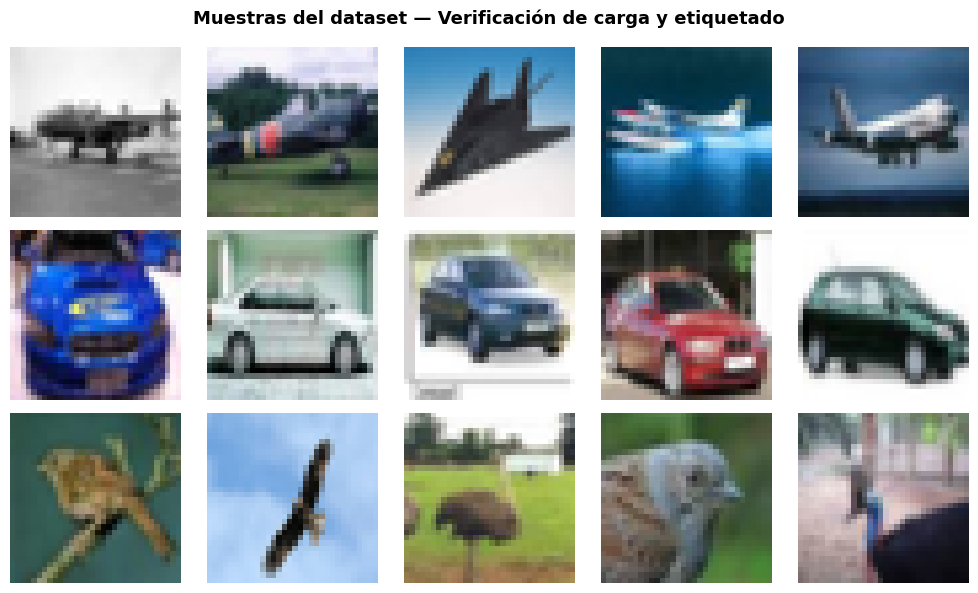

[Visualización] Imagen guardada como 'muestras_dataset.png'


In [4]:
# =============================================================
# PASO 3B — VISUALIZACIÓN DE MUESTRAS DEL DATASET
# =============================================================
# Mostramos 5 imágenes de cada clase para verificar la carga
# y el etiquetado correcto.

N_MOSTRAR = 5
fig, axes = plt.subplots(N_CLASES, N_MOSTRAR, figsize=(N_MOSTRAR * 2, N_CLASES * 2))
fig.suptitle("Muestras del dataset — Verificación de carga y etiquetado",
             fontsize=13, fontweight="bold")

for clase_idx, nombre in enumerate(nombres_clases):
    # Índices del split de entrenamiento que pertenecen a esta clase
    indices_clase = np.where(y_train == clase_idx)[0]
    seleccion     = np.random.choice(indices_clase, N_MOSTRAR, replace=False)

    for col, idx in enumerate(seleccion):
        ax = axes[clase_idx, col]
        ax.imshow(X_train[idx])   # imshow espera [0,1] float o [0,255] uint8
        ax.axis("off")
        if col == 0:
            ax.set_ylabel(nombre, fontsize=10, fontweight="bold", rotation=90,
                          labelpad=8, va="center")

plt.tight_layout()
plt.savefig("muestras_dataset.png", dpi=100, bbox_inches="tight")
plt.show()
print("[Visualización] Imagen guardada como 'muestras_dataset.png'")

### ✏️ COMPLETAR — Descripción técnica del dataset

Completa la siguiente tabla con los datos de tu dataset:

| Campo | Valor |
|-------|-------|
| Número de clases | *(escribe aquí)* |
| Imágenes por clase (train) | *(escribe aquí)* |
| Imágenes por clase (val) | *(escribe aquí)* |
| Imágenes por clase (test) | *(escribe aquí)* |
| Resolución de cada imagen | *(escribe aquí)* |
| Canales | *(RGB / Escala de grises)* |
| Fuente | *(Sintético / CIFAR-10 / Propia)* |
| Rango de valores de píxel | *(escribe aquí)* |

---
## Paso 4 — Modelo CNN: Arquitectura, Entrenamiento y Evaluación

### Opciones de arquitectura

El notebook implementa **dos opciones**. Elige una cambiando la variable
`OPCION_MODELO` en la primera celda de código de este paso:

| Opción | Arquitectura | Cuándo usarla |
|--------|-------------|---------------|
| **`'A'`** | CNN desde cero (2 bloques Conv+Pool + 2 densas) | Para entender cada componente desde cero |
| **`'B'`** | Transfer Learning con MobileNetV2 | Cuando el dataset es pequeño o el tiempo es limitado |

> **Conexión con Tema 2:** Las capas `Conv2D` *aprenden automáticamente* los filtros
> que en el Tema 2 diseñamos a mano (Sobel, Gaussiano, Laplaciano).
> En el Paso 6 visualizaremos estos filtros aprendidos.


In [5]:
# =============================================================
# PASO 4B — SELECCIÓN Y DEFINICIÓN DE LA ARQUITECTURA
# =============================================================

# ── Elige aquí la arquitectura ────────────────────────────────
# 'A' → CNN sencilla desde cero (recomendada para aprendizaje)
# 'B' → Transfer Learning con MobileNetV2 (más rápido)
OPCION_MODELO = 'A'

print(f"[Modelo] Opción: {OPCION_MODELO} | "
      f"Clases: {N_CLASES} | Input: ({IMG_SIZE},{IMG_SIZE},3)")
print("-" * 60)

def construir_cnn_desde_cero(n_clases: int, img_size: int) -> keras.Model:
    """
    Construye una CNN sencilla desde cero.

    Arquitectura:
      Input (img_size, img_size, 3)
        → Conv2D(32, 3x3, ReLU) → MaxPool2D(2x2)
        → Conv2D(64, 3x3, ReLU) → MaxPool2D(2x2)
        → Flatten
        → Dense(128, ReLU) → Dropout(0.4)
        → Dense(n_clases, softmax)

    Componentes clave:
    - Conv2D      : extrae características locales (aprende filtros — Tema 2)
    - MaxPool2D   : reduce dimensionalidad, aporta invarianza a traslaciones
    - ReLU        : función de activación no lineal
    - Dropout     : regularización para evitar sobreajuste (overfitting)
    - Softmax     : convierte activaciones en probabilidades por clase
    """
    modelo = models.Sequential(name="CNN_desde_cero", layers=[
        # ── Bloque 1: detección de bordes y texturas simples ────
        layers.Input(shape=(img_size, img_size, 3)),
        layers.Conv2D(32, (3, 3), activation="relu", padding="same",
                      name="conv1"),
        layers.MaxPooling2D((2, 2), name="pool1"),

        # ── Bloque 2: detección de patrones más complejos ────────
        layers.Conv2D(64, (3, 3), activation="relu", padding="same",
                      name="conv2"),
        layers.MaxPooling2D((2, 2), name="pool2"),

        # ── Cabeza de clasificación ──────────────────────────────
        layers.Flatten(name="flatten"),
        layers.Dense(128, activation="relu", name="dense1"),
        layers.Dropout(0.4, name="dropout"),        # reduce sobreajuste
        layers.Dense(n_clases, activation="softmax", name="salida")
    ])
    return modelo


def construir_mobilenet_transfer(n_clases: int, img_size: int) -> keras.Model:
    """
    Transfer Learning con MobileNetV2 preentrenado en ImageNet.

    Estrategia:
    - Se congelan TODOS los pesos de la base MobileNetV2.
    - Solo se entrenan las capas densas agregadas al final.
    - Útil cuando el dataset es pequeño: aprovecha representaciones
      aprendidas con millones de imágenes.

    NOTA: Requiere que IMG_SIZE >= 32. MobileNetV2 espera >= 32x32.
          Si el tamaño es muy pequeño, incluimos un Resizing.
    """
    # Redimensionar si la imagen es muy pequeña para MobileNetV2
    tam_base = max(img_size, 96)   # mínimo recomendado: 96x96

    base = keras.applications.MobileNetV2(
        input_shape=(tam_base, tam_base, 3),
        include_top=False,           # excluir la capa de clasificación original
        weights="imagenet"           # pesos preentrenados
    )
    base.trainable = False           # congelar todos los pesos de la base

    entrada  = layers.Input(shape=(img_size, img_size, 3))
    x = entrada

    # Redimensionar si es necesario
    if img_size < tam_base:
        x = layers.Resizing(tam_base, tam_base)(x)

    # Preprocesamiento esperado por MobileNetV2: rango [-1, 1]
    x = keras.applications.mobilenet_v2.preprocess_input(x)

    x = base(x, training=False)            # inferencia en la base congelada
    x = layers.GlobalAveragePooling2D()(x) # reduce el mapa de características
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.4)(x)
    salida = layers.Dense(n_clases, activation="softmax", name="salida")(x)

    return keras.Model(inputs=entrada, outputs=salida, name="MobileNetV2_TL")


# ── Instanciar el modelo elegido ───────────────────────────────
if OPCION_MODELO == 'A':
    modelo = construir_cnn_desde_cero(N_CLASES, IMG_SIZE)
else:
    modelo = construir_mobilenet_transfer(N_CLASES, IMG_SIZE)

# ── Compilar ───────────────────────────────────────────────────
# - optimizer  : Adam adapta la tasa de aprendizaje durante el entrenamiento
# - loss       : categorical_crossentropy para clasificación multiclase
# - metrics    : accuracy = fracción de predicciones correctas
modelo.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss="sparse_categorical_crossentropy",  # etiquetas como enteros (no one-hot)
    metrics=["accuracy"]
)

# ── Resumen de la arquitectura ─────────────────────────────────
modelo.summary()

[Modelo] Opción: A | Clases: 3 | Input: (32,32,3)
------------------------------------------------------------


Model: "CNN_desde_cero"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1 (Conv2D)              (None, 32, 32, 32)        896       
                                                                 
 pool1 (MaxPooling2D)        (None, 16, 16, 32)        0         
                                                                 
 conv2 (Conv2D)              (None, 16, 16, 64)        18496     
                                                                 
 pool2 (MaxPooling2D)        (None, 8, 8, 64)          0         
                                                                 
 flatten (Flatten)           (None, 4096)              0         
                                                                 
 dense1 (Dense)              (None, 128)               524416    
     

In [6]:
# =============================================================
# PASO 4C — ENTRENAMIENTO DEL MODELO
# =============================================================

# ── Callbacks ─────────────────────────────────────────────────
# EarlyStopping: detiene el entrenamiento si val_loss no mejora
#   en 'patience' épocas seguidas → evita sobreajuste
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
    verbose=1
)

# ReduceLROnPlateau: reduce la tasa de aprendizaje si el modelo
#   se estanca → ayuda a salir de mínimos locales
reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

print(f"[Entrenamiento] Iniciando — {EPOCAS} épocas máx, batch={BATCH_SIZE}")
print("-" * 60)

historial = modelo.fit(
    X_train, y_train,
    epochs=EPOCAS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

print("-" * 60)
print(f"[Entrenamiento] Épocas completadas: {len(historial.history['loss'])}")

[Entrenamiento] Iniciando — 10 épocas máx, batch=32
------------------------------------------------------------
Epoch 1/10


469/469 [==============================] - 29s 47ms/step - loss: 0.5755 - accuracy: 0.7631 - val_loss: 0.3843 - val_accuracy: 0.8447 - lr: 0.0010
Epoch 2/10
469/469 [==============================] - 16s 33ms/step - loss: 0.3881 - accuracy: 0.8478 - val_loss: 0.3126 - val_accuracy: 0.8707 - lr: 0.0010
Epoch 3/10
469/469 [==============================] - 12s 26ms/step - loss: 0.3221 - accuracy: 0.8766 - val_loss: 0.2874 - val_accuracy: 0.8907 - lr: 0.0010
Epoch 4/10
469/469 [==============================] - 12s 25ms/step - loss: 0.2861 - accuracy: 0.8911 - val_loss: 0.2755 - val_accuracy: 0.8833 - lr: 0.0010
Epoch 5/10
469/469 [==============================] - 12s 25ms/step - loss: 0.2441 - accuracy: 0.9056 - val_loss: 0.2897 - val_accuracy: 0.8887 - lr: 0.0010
Epoch 6/10
469/469 [==============================] - 12s 26ms/step - loss: 0.2173 - accuracy: 0.917

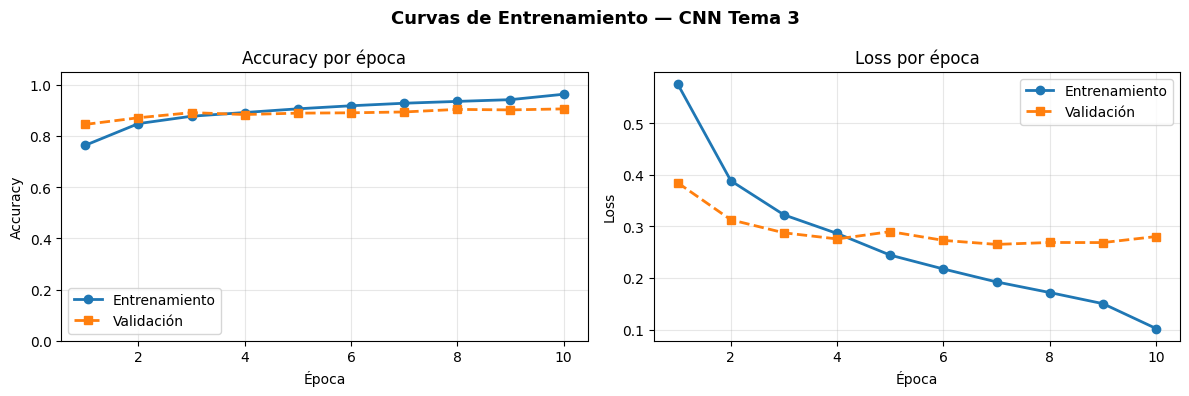

[Gráfica] Guardada como 'curvas_entrenamiento.png'


In [7]:
# =============================================================
# PASO 4D — CURVAS DE ENTRENAMIENTO
# =============================================================
# Visualizamos accuracy y loss para train y validación.
# Una brecha grande entre ambas curvas indica sobreajuste (overfitting).

n_epocas_reales = len(historial.history["loss"])
epocas_eje      = range(1, n_epocas_reales + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Curvas de Entrenamiento — CNN Tema 3",
             fontsize=13, fontweight="bold")

# ── Accuracy ──────────────────────────────────────────────────
ax1.plot(epocas_eje, historial.history["accuracy"],
         label="Entrenamiento", marker="o", linewidth=2)
ax1.plot(epocas_eje, historial.history["val_accuracy"],
         label="Validación",    marker="s", linewidth=2, linestyle="--")
ax1.set_title("Accuracy por época")
ax1.set_xlabel("Época")
ax1.set_ylabel("Accuracy")
ax1.set_ylim(0, 1.05)
ax1.legend()
ax1.grid(True, alpha=0.3)

# ── Loss ──────────────────────────────────────────────────────
ax2.plot(epocas_eje, historial.history["loss"],
         label="Entrenamiento", marker="o", linewidth=2)
ax2.plot(epocas_eje, historial.history["val_loss"],
         label="Validación",    marker="s", linewidth=2, linestyle="--")
ax2.set_title("Loss por época")
ax2.set_xlabel("Época")
ax2.set_ylabel("Loss")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("curvas_entrenamiento.png", dpi=100, bbox_inches="tight")
plt.show()
print("[Gráfica] Guardada como 'curvas_entrenamiento.png'")

In [8]:
# =============================================================
# PASO 4E — EVALUACIÓN EN CONJUNTO DE PRUEBA
# =============================================================

# ── Predicciones ──────────────────────────────────────────────
y_prob  = modelo.predict(X_test, verbose=0)   # probabilidades por clase
y_pred  = np.argmax(y_prob, axis=1)           # clase con mayor probabilidad
y_true  = y_test

# ── Métricas globales ──────────────────────────────────────────
acc_test = accuracy_score(y_true, y_pred)
print("=" * 50)
print(f" Accuracy en prueba : {acc_test:.4f} ({acc_test*100:.1f} %)")
print("=" * 50)

# ── Reporte por clase ──────────────────────────────────────────
# Precisión  : de todas las predichas como clase X, ¿cuántas sí lo eran?
# Recall     : de todas las que sí eran clase X, ¿cuántas fueron detectadas?
# F1-score   : media armónica de precisión y recall
print("\nReporte de clasificación:")
print(classification_report(y_true, y_pred, target_names=nombres_clases))

 Accuracy en prueba : 0.9013 (90.1 %)

Reporte de clasificación:
              precision    recall  f1-score   support

       avion       0.87      0.91      0.89       513
        auto       0.95      0.90      0.93       498
      pajaro       0.89      0.89      0.89       489

    accuracy                           0.90      1500
   macro avg       0.90      0.90      0.90      1500
weighted avg       0.90      0.90      0.90      1500



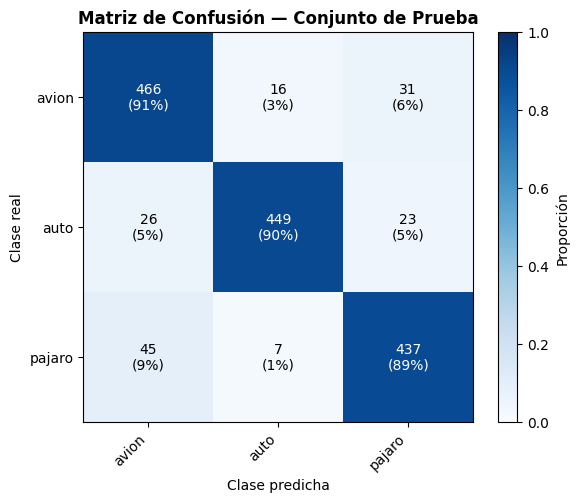

[Gráfica] Guardada como 'matriz_confusion.png'


In [9]:
# =============================================================
# PASO 4F — MATRIZ DE CONFUSIÓN
# =============================================================
# Filas = clase real | Columnas = clase predicha
# La diagonal principal = predicciones correctas
# Fuera de la diagonal = errores (falsos positivos/negativos)

def graficar_matriz_confusion(y_true, y_pred, clases, titulo="Matriz de Confusión"):
    """
    Grafica la matriz de confusión con valores absolutos y porcentuales.

    Parámetros
    ----------
    y_true : etiquetas reales
    y_pred : etiquetas predichas
    clases : lista de nombres de clases
    titulo : título de la figura
    """
    cm = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype(np.float32) / cm.sum(axis=1, keepdims=True)  # por fila

    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(cm_norm, interpolation="nearest", cmap=plt.cm.Blues, vmin=0, vmax=1)
    plt.colorbar(im, ax=ax, label="Proporción")

    tick_marks = np.arange(len(clases))
    ax.set_xticks(tick_marks);  ax.set_xticklabels(clases, rotation=45, ha="right")
    ax.set_yticks(tick_marks);  ax.set_yticklabels(clases)

    umbral = 0.5
    for i in range(len(clases)):
        for j in range(len(clases)):
            color_txt = "white" if cm_norm[i, j] > umbral else "black"
            ax.text(j, i, f"{cm[i,j]}\n({cm_norm[i,j]:.0%})",
                    ha="center", va="center",
                    color=color_txt, fontsize=10)

    ax.set_title(titulo, fontsize=12, fontweight="bold")
    ax.set_ylabel("Clase real")
    ax.set_xlabel("Clase predicha")
    plt.tight_layout()
    return fig


fig_cm = graficar_matriz_confusion(y_true, y_pred, nombres_clases,
                                    titulo="Matriz de Confusión — Conjunto de Prueba")
fig_cm.savefig("matriz_confusion.png", dpi=100, bbox_inches="tight")
plt.show()
print("[Gráfica] Guardada como 'matriz_confusion.png'")

### ✏️ COMPLETAR — Descripción del modelo y parámetros

Completa con los valores que usaste:

| Campo | Valor |
|-------|-------|
| Opción de modelo | *(A / B)* |
| Número de épocas entrenadas | *(escribe aquí)* |
| Batch size | *(escribe aquí)* |
| Learning rate inicial | *(escribe aquí)* |
| Accuracy final en validación | *(escribe aquí)* |
| Accuracy en prueba | *(escribe aquí)* |
| ¿Se activó EarlyStopping? | *(Sí / No — en qué época)* |

---
## Paso 5 — Rastreo de Objetos (Object Tracking)

### ¿Qué es el rastreo y cómo se diferencia de la detección?

| | Detección | Rastreo |
|-|-----------|---------|
| **Qué hace** | Identifica objetos en UN cuadro | Sigue objetos A LO LARGO del tiempo |
| **Entrada** | Una imagen | Secuencia de imágenes/video |
| **Salida** | Clase + posición | Clase + posición + **identidad persistente** |

### Método implementado: Centroide-Based Tracker

1. Cada objeto detectado recibe un **ID único** basado en su centroide `(cx, cy)`.
2. En cada nuevo cuadro, calculamos la **distancia euclidiana** entre todos los
   centroides actuales y los del cuadro anterior.
3. Asignamos el ID al centroide más cercano (si está dentro del umbral).
4. Si un objeto no reaparece en N cuadros, se **elimina** de la memoria.

> **Alternativas documentadas en el código:**
> - `cv2.TrackerCSRT_create()` — más robusto a oclusiones, misma API de OpenCV
> - `cv2.TrackerKCF_create()` — más rápido pero menos preciso
> - SORT — usa filtro de Kalman + Hungarian algorithm (instalar `sort-tracker-py`)

In [10]:
# =============================================================
# PASO 5A — CLASE CentroideTracker
# =============================================================

class CentroideTracker:
    """
    Rastreo simple de objetos basado en distancia entre centroides.

    Algoritmo:
    1. Recibe una lista de bounding boxes (x1, y1, x2, y2) por cuadro.
    2. Calcula el centroide de cada box.
    3. Compara con centroides registrados usando distancia euclidiana.
    4. Asigna el ID del objeto más cercano (si dist < umbral).
    5. Registra cuadros ausentes; elimina objetos tras `max_desap` cuadros sin aparecer.

    Atributos
    ---------
    next_id       : int — próximo ID a asignar
    objetos       : OrderedDict[id → centroide]
    desaparecidos : OrderedDict[id → cuadros_sin_ver]
    """

    def __init__(self, max_desap: int = 10, umbral_dist: int = 50):
        """
        Parámetros
        ----------
        max_desap   : cuadros consecutivos sin detección antes de eliminar el objeto
        umbral_dist : distancia máxima (px) para considerar que dos centroides
                      corresponden al mismo objeto
        """
        self.next_id       = 0
        self.objetos       = OrderedDict()   # id → (cx, cy)
        self.desaparecidos = OrderedDict()   # id → cuadros ausente
        self.max_desap     = max_desap
        self.umbral_dist   = umbral_dist

    def _registrar(self, centroide):
        """Añade un objeto nuevo con el siguiente ID disponible."""
        self.objetos[self.next_id]       = centroide
        self.desaparecidos[self.next_id] = 0
        self.next_id += 1

    def _eliminar(self, obj_id):
        """Elimina un objeto que ha desaparecido demasiados cuadros."""
        del self.objetos[obj_id]
        del self.desaparecidos[obj_id]

    def actualizar(self, bboxes):
        """
        Actualiza el estado del tracker con las detecciones del cuadro actual.

        Parámetros
        ----------
        bboxes : list of (x1, y1, x2, y2) — bounding boxes detectadas

        Retorna
        -------
        dict[id → centroide] — objetos actualmente rastreados
        """
        # ── Sin detecciones en este cuadro ─────────────────────
        if len(bboxes) == 0:
            for obj_id in list(self.desaparecidos.keys()):
                self.desaparecidos[obj_id] += 1
                if self.desaparecidos[obj_id] > self.max_desap:
                    self._eliminar(obj_id)
            return dict(self.objetos)

        # ── Calcular centroides de las nuevas detecciones ────────
        centroides_nuevos = np.array([
            ((x1 + x2) // 2, (y1 + y2) // 2)
            for (x1, y1, x2, y2) in bboxes
        ], dtype=np.float32)

        # ── Sin objetos registrados aún → registrar todos ────────
        if len(self.objetos) == 0:
            for c in centroides_nuevos:
                self._registrar(c)
            return dict(self.objetos)

        # ── Asociar nuevos centroides con los ya registrados ─────
        # Matriz de distancias: filas=objetos_actuales, cols=nuevos_centroides
        ids_actuales     = list(self.objetos.keys())
        centroides_prev  = np.array(list(self.objetos.values()), dtype=np.float32)

        # distancia euclidiana entre cada par (prev, nuevo)
        D = dist.cdist(centroides_prev, centroides_nuevos)

        # Ordenar por distancia mínima en cada fila, luego columnas
        filas = D.min(axis=1).argsort()       # objetos ordenados por su mejor match
        cols  = D.argmin(axis=1)[filas]        # índice del centroide más cercano

        filas_usadas = set()
        cols_usadas  = set()

        for (fila, col) in zip(filas, cols):
            if fila in filas_usadas or col in cols_usadas:
                continue
            if D[fila, col] > self.umbral_dist:
                continue   # demasiado lejos → no es el mismo objeto

            obj_id = ids_actuales[fila]
            self.objetos[obj_id]       = centroides_nuevos[col]
            self.desaparecidos[obj_id] = 0
            filas_usadas.add(fila)
            cols_usadas.add(col)

        # ── Cuadros sin emparejamiento → actualizar desaparición ─
        filas_sin_match = set(range(len(ids_actuales))) - filas_usadas
        for fila in filas_sin_match:
            obj_id = ids_actuales[fila]
            self.desaparecidos[obj_id] += 1
            if self.desaparecidos[obj_id] > self.max_desap:
                self._eliminar(obj_id)

        # ── Nuevas detecciones sin asignar → nuevos objetos ──────
        cols_sin_match = set(range(len(centroides_nuevos))) - cols_usadas
        for col in cols_sin_match:
            self._registrar(centroides_nuevos[col])

        return dict(self.objetos)


print("[Tracker] Clase CentroideTracker definida correctamente.")
print()
print("=" * 60)
print(" ALTERNATIVAS DE TRACKER (solo informativo, no requieren instalación)")
print("=" * 60)
print("""
 ➊ OpenCV CSRT (más robusto a oclusiones):
     tracker = cv2.TrackerCSRT_create()
     tracker.init(primer_cuadro, bbox_inicial)
     ok, bbox = tracker.update(cuadro_siguiente)

 ➋ OpenCV KCF (más rápido, menos preciso):
     tracker = cv2.TrackerKCF_create()
     (misma API que CSRT)

 ➌ SORT (filtro de Kalman + Hungarian algorithm):
     pip install sort-tracker-py
     from sort import Sort
     tracker = Sort(max_age=10, min_hits=3)
     tracks = tracker.update(np.array([[x1,y1,x2,y2,score],...]))

 El CentroideTracker implementado aquí es el más pedagógico
 y no requiere dependencias adicionales.
""")

[Tracker] Clase CentroideTracker definida correctamente.

 ALTERNATIVAS DE TRACKER (solo informativo, no requieren instalación)

 ➊ OpenCV CSRT (más robusto a oclusiones):
     tracker = cv2.TrackerCSRT_create()
     tracker.init(primer_cuadro, bbox_inicial)
     ok, bbox = tracker.update(cuadro_siguiente)

 ➋ OpenCV KCF (más rápido, menos preciso):
     tracker = cv2.TrackerKCF_create()
     (misma API que CSRT)

 ➌ SORT (filtro de Kalman + Hungarian algorithm):
     pip install sort-tracker-py
     from sort import Sort
     tracker = Sort(max_age=10, min_hits=3)
     tracks = tracker.update(np.array([[x1,y1,x2,y2,score],...]))

 El CentroideTracker implementado aquí es el más pedagógico
 y no requiere dependencias adicionales.



[Secuencia] Generando video de prueba...
[Secuencia] 30 cuadros generados
[Secuencia] Objetos: 3 | clases: ['avion', 'auto', 'pajaro']


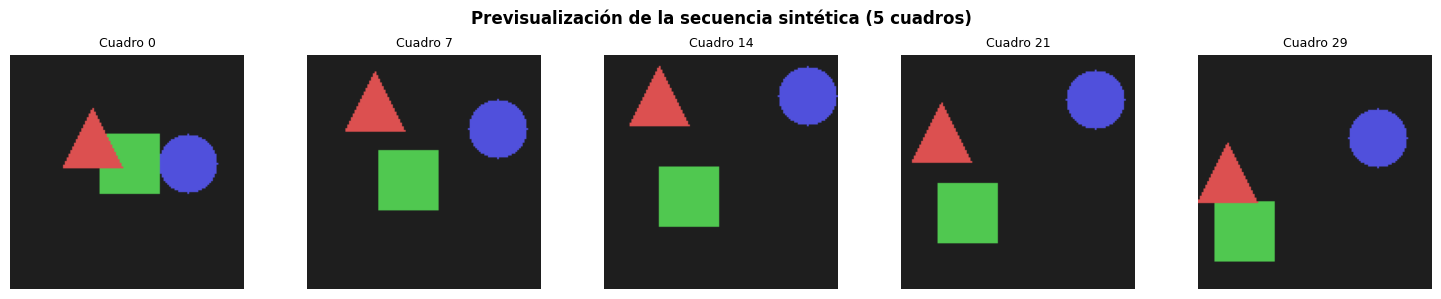

[Gráfica] Guardada como 'secuencia_preview.png'


In [11]:
# =============================================================
# PASO 5B — GENERACIÓN DE SECUENCIA DE VIDEO SINTÉTICA
# =============================================================
# Se generan cuadros donde objetos se mueven por la escena.
# Esto simula una cámara fija observando objetos en movimiento
# (banda transportadora, tráfico, etc.).

def generar_secuencia_de_prueba(
    n_cuadros:  int = 30,
    n_objetos:  int = 3,
    alto:       int = 128,
    ancho:      int = 128,
    tam_objeto: int = 18
):
    """
    Genera una secuencia de cuadros (lista de np.ndarray BGR uint8)
    con objetos de distintas formas moviéndose linealmente.

    Retorna
    -------
    cuadros    : list[np.ndarray]  — cada elemento es un cuadro BGR
    trayectorias : list[list[tuple]] — posiciones (cx,cy) por objeto por cuadro
    clases_obj  : list[int] — clase de cada objeto (0=círculo,1=cuad,2=triáng)
    """
    # Definir propiedades iniciales de cada objeto
    colores = [
        (220, 80,  80),    # azul claro  (BGR)
        (80,  200, 80),    # verde
        (80,  80,  220),   # rojo
        (200, 200, 50),    # cian
        (200, 50,  200),   # magenta
    ]

    objetos_info = []
    for i in range(n_objetos):
        clase = i % 3
        # Posición inicial aleatoria con margen
        cx0 = np.random.randint(tam_objeto, ancho - tam_objeto)
        cy0 = np.random.randint(tam_objeto, alto  - tam_objeto)
        # Velocidad: dirección aleatoria
        vx  = np.random.uniform(-3, 3)
        vy  = np.random.uniform(-3, 3)
        # Evitar velocidades casi nulas
        vx  = vx if abs(vx) > 0.5 else 1.0
        vy  = vy if abs(vy) > 0.5 else 1.0
        color = colores[i % len(colores)]
        objetos_info.append({"clase": clase, "cx": cx0, "cy": cy0,
                              "vx": vx,       "vy": vy, "color": color})

    cuadros      = []
    trayectorias = [[] for _ in range(n_objetos)]
    clases_obj   = [obj["clase"] for obj in objetos_info]

    for _ in range(n_cuadros):
        fondo = np.ones((alto, ancho, 3), dtype=np.uint8) * 30  # fondo oscuro

        for i, obj in enumerate(objetos_info):
            cx, cy = int(obj["cx"]), int(obj["cy"])
            r      = tam_objeto
            color  = obj["color"]
            clase  = obj["clase"]

            # Dibujar según clase
            if clase == 0:   # círculo
                cv2.circle(fondo, (cx, cy), r, color, -1)
            elif clase == 1:   # cuadrado
                cv2.rectangle(fondo, (cx-r, cy-r), (cx+r, cy+r), color, -1)
            elif clase == 2:   # triángulo
                pts = np.array([[cx, cy-r], [cx-r, cy+r], [cx+r, cy+r]], np.int32)
                cv2.fillPoly(fondo, [pts], color)

            trayectorias[i].append((cx, cy))

            # Mover con rebote en bordes
            obj["cx"] += obj["vx"]
            obj["cy"] += obj["vy"]
            if obj["cx"] <= r or obj["cx"] >= ancho - r:  obj["vx"] *= -1
            if obj["cy"] <= r or obj["cy"] >= alto  - r:  obj["vy"] *= -1

        cuadros.append(fondo)

    return cuadros, trayectorias, clases_obj


# ── Generar secuencia ──────────────────────────────────────────
print("[Secuencia] Generando video de prueba...")
cuadros_secuencia, trayectorias_gt, clases_objetos = generar_secuencia_de_prueba(
    n_cuadros=30, n_objetos=3, alto=128, ancho=128, tam_objeto=16
)
print(f"[Secuencia] {len(cuadros_secuencia)} cuadros generados")
print(f"[Secuencia] Objetos: {len(clases_objetos)} | clases: {[nombres_clases[c] for c in clases_objetos]}")

# ── Previsualización de 5 cuadros ──────────────────────────────
indices_prev = np.linspace(0, len(cuadros_secuencia)-1, 5, dtype=int)
fig, axes   = plt.subplots(1, 5, figsize=(15, 3))
fig.suptitle("Previsualización de la secuencia sintética (5 cuadros)",
             fontsize=12, fontweight="bold")
for ax, idx in zip(axes, indices_prev):
    ax.imshow(cv2.cvtColor(cuadros_secuencia[idx], cv2.COLOR_BGR2RGB))
    ax.set_title(f"Cuadro {idx}", fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.savefig("secuencia_preview.png", dpi=100, bbox_inches="tight")
plt.show()
print("[Gráfica] Guardada como 'secuencia_preview.png'")

In [12]:
# =============================================================
# PASO 5C — DETECTOR DE OBJETOS SIMPLE (umbralización + contornos)
# =============================================================
# Para la secuencia sintética usamos umbralización + detección de
# contornos de OpenCV como "detector". En un sistema real este paso
# se reemplazaría por un modelo YOLO / SSD / Faster-RCNN.

def detectar_objetos_por_contornos(
    cuadro:     np.ndarray,
    min_area:   int = 50,
    max_area:   int = 5000
):
    """
    Detecta bounding boxes de objetos brillantes sobre fondo oscuro.

    Pasos internos:
    1. Convertir a escala de grises
    2. Umbralizar (threshold) para segmentar objeto vs. fondo
    3. Encontrar contornos y calcular sus bounding boxes
    4. Filtrar por área mínima y máxima

    Retorna
    -------
    bboxes : list of (x1, y1, x2, y2)
    recortes : list of np.ndarray — parche de la imagen para cada bbox
    """
    gris   = cv2.cvtColor(cuadro, cv2.COLOR_BGR2GRAY)
    _, bin = cv2.threshold(gris, 40, 255, cv2.THRESH_BINARY)

    # Operaciones morfológicas para unir regiones fragmentadas
    kernel = np.ones((3, 3), np.uint8)
    bin    = cv2.morphologyEx(bin, cv2.MORPH_CLOSE, kernel)

    contornos, _ = cv2.findContours(bin, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    bboxes   = []
    recortes = []

    for cnt in contornos:
        area = cv2.contourArea(cnt)
        if area < min_area or area > max_area:
            continue
        x, y, w, h = cv2.boundingRect(cnt)
        bboxes.append((x, y, x + w, y + h))

        # Extraer parche y redimensionar para la CNN
        parche = cuadro[y:y+h, x:x+w]
        parche = cv2.resize(parche, (IMG_SIZE, IMG_SIZE))
        recortes.append(parche)

    return bboxes, recortes


# ── Prueba rápida del detector en el primer cuadro ────────────
bboxes_prueba, recortes_prueba = detectar_objetos_por_contornos(cuadros_secuencia[0])
print(f"[Detector] Cuadro 0: {len(bboxes_prueba)} objeto(s) detectado(s)")
for i, (bb, rec) in enumerate(zip(bboxes_prueba, recortes_prueba)):
    prob = modelo.predict(rec[np.newaxis].astype(np.float32) / 255.0, verbose=0)[0]
    clase_pred = nombres_clases[np.argmax(prob)]
    print(f"  Objeto {i}: bbox={bb} → predicción='{clase_pred}' ({prob.max():.1%})")

[Detector] Cuadro 0: 1 objeto(s) detectado(s)
  Objeto 0: bbox=(29, 29, 114, 76) → predicción='pajaro' (72.1%)


In [13]:
# =============================================================
# PASO 5D — PIPELINE COMPLETO: DETECCIÓN + CLASIFICACIÓN + RASTREO
# =============================================================

# ── Colores para dibujar cada ID (hasta 10 objetos) ───────────
COLORES_ID = [
    (255, 50,  50),   # rojo
    (50,  255, 50),   # verde
    (50,  50,  255),  # azul
    (255, 200, 0),    # amarillo
    (200, 0,   255),  # violeta
    (0,   200, 255),  # cian
    (255, 100, 200),  # rosa
    (100, 255, 200),  # verde claro
    (200, 100, 50),   # naranja
    (50,  100, 200),  # azul marino
]

tracker = CentroideTracker(max_desap=5, umbral_dist=40)
cuadros_anotados = []

for num_cuadro, cuadro in enumerate(cuadros_secuencia):
    # ── 1. Detectar objetos en el cuadro actual ────────────────
    bboxes, recortes = detectar_objetos_por_contornos(cuadro)

    # ── 2. Clasificar cada región detectada ────────────────────
    clases_predichas = []
    confianzas       = []

    for recorte in recortes:
        parche_norm = recorte.astype(np.float32) / 255.0
        parche_batch = parche_norm[np.newaxis]   # añadir dimensión de batch
        probs = modelo.predict(parche_batch, verbose=0)[0]
        clases_predichas.append(np.argmax(probs))
        confianzas.append(probs.max())

    # ── 3. Actualizar tracker con las bboxes del cuadro ───────
    objetos_rastreados = tracker.actualizar(bboxes)

    # ── 4. Dibujar anotaciones ─────────────────────────────────
    cuadro_anotado = cuadro.copy()

    for (bbox_idx, (x1, y1, x2, y2)) in enumerate(bboxes):
        # Determinar el ID del tracker más cercano a este bbox
        cx_det = (x1 + x2) // 2
        cy_det = (y1 + y2) // 2

        id_asignado    = -1
        dist_min_local = float("inf")
        for obj_id, centroide in objetos_rastreados.items():
            d = np.linalg.norm(np.array([cx_det, cy_det]) - np.array(centroide))
            if d < dist_min_local:
                dist_min_local = d
                id_asignado    = obj_id

        # Seleccionar color según ID
        color = COLORES_ID[id_asignado % len(COLORES_ID)] if id_asignado >= 0 else (200, 200, 200)

        # Dibujar bounding box
        cv2.rectangle(cuadro_anotado, (x1, y1), (x2, y2), color, 2)

        # Etiqueta: clase predicha + confianza + ID
        if bbox_idx < len(clases_predichas):
            clase_nom = nombres_clases[clases_predichas[bbox_idx]]
            conf      = confianzas[bbox_idx]
            etiqueta  = f"ID:{id_asignado} {clase_nom} {conf:.0%}"
        else:
            etiqueta = f"ID:{id_asignado}"

        # Fondo del texto para legibilidad
        (tw, th), _ = cv2.getTextSize(etiqueta, cv2.FONT_HERSHEY_SIMPLEX, 0.35, 1)
        cv2.rectangle(cuadro_anotado, (x1, y1 - th - 4), (x1 + tw, y1), color, -1)
        cv2.putText(cuadro_anotado, etiqueta,
                    (x1, y1 - 2),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.35, (255, 255, 255), 1)

        # Punto en el centroide
        cv2.circle(cuadro_anotado, (cx_det, cy_det), 3, color, -1)

    # ── Número de cuadro en la esquina ────────────────────────
    cv2.putText(cuadro_anotado, f"Cuadro: {num_cuadro:02d}",
                (3, 10), cv2.FONT_HERSHEY_SIMPLEX, 0.35, (200, 200, 200), 1)

    cuadros_anotados.append(cuadro_anotado)

print(f"[Tracking] Procesados {len(cuadros_anotados)} cuadros")
print(f"[Tracking] IDs activos al final: {list(tracker.objetos.keys())}")
print(f"[Tracking] Total de IDs asignados: {tracker.next_id}")

[Tracking] Procesados 30 cuadros
[Tracking] IDs activos al final: [0, 1, 2]
[Tracking] Total de IDs asignados: 3


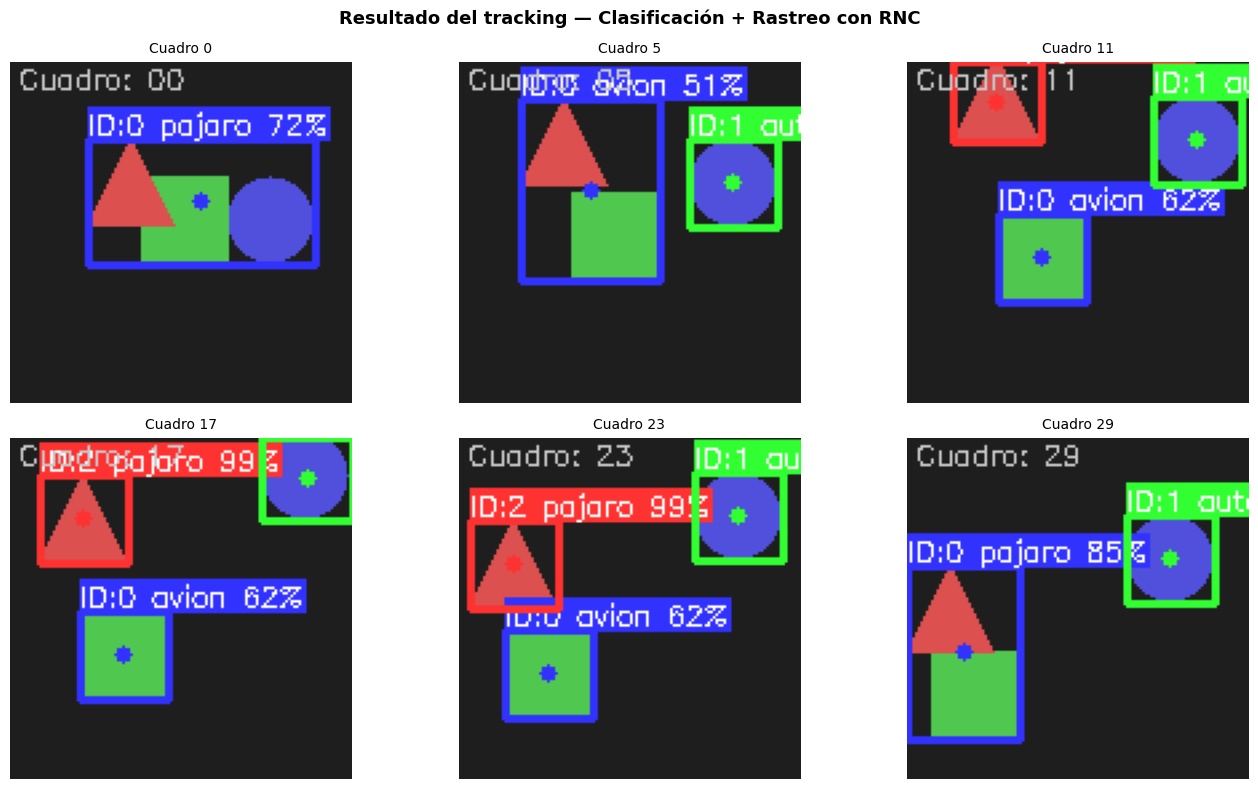

[Gráfica] Guardada como 'tracking_resultado.png'
[Video] Guardado como 'tracking_output.mp4' (5 fps)


In [14]:
# =============================================================
# PASO 5E — VISUALIZACIÓN DEL TRACKING
# =============================================================

# ── Cuadrícula de cuadros anotados ────────────────────────────
indices_vis = np.linspace(0, len(cuadros_anotados)-1, 6, dtype=int)
fig, axes   = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle("Resultado del tracking — Clasificación + Rastreo con RNC",
             fontsize=13, fontweight="bold")

for ax, idx in zip(axes.flat, indices_vis):
    img_rgb = cv2.cvtColor(cuadros_anotados[idx], cv2.COLOR_BGR2RGB)
    ax.imshow(img_rgb)
    ax.set_title(f"Cuadro {idx}", fontsize=10)
    ax.axis("off")

plt.tight_layout()
plt.savefig("tracking_resultado.png", dpi=120, bbox_inches="tight")
plt.show()
print("[Gráfica] Guardada como 'tracking_resultado.png'")

# ── Guardar video de salida (opcional) ────────────────────────
alto_v, ancho_v = cuadros_anotados[0].shape[:2]
fourcc = cv2.VideoWriter_fourcc(*"mp4v")
writer = cv2.VideoWriter("tracking_output.mp4", fourcc, 5,
                          (ancho_v, alto_v))
for c in cuadros_anotados:
    writer.write(c)
writer.release()
print("[Video] Guardado como 'tracking_output.mp4' (5 fps)")

---
## Paso 6 — Análisis de Resultados y Reflexión

Este paso combina análisis técnico (código) y reflexión crítica (texto).

### 6.1 — Visualización de filtros aprendidos (conexión con Tema 2)
### 6.2 — Análisis de errores de clasificación
### 6.3 — Reflexión escrita

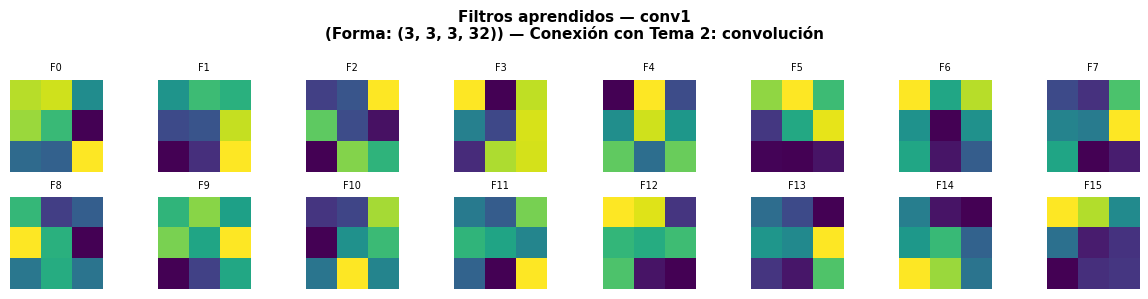

[Gráfica] 16 filtros de 'conv1' guardados como 'filtros_aprendidos.png'
[Reflexión] Compara estos filtros con los kernels del Tema 2 (Sobel, Gaussiano).
            ¿Ves patrones de detección de bordes o gradientes?


In [15]:
# =============================================================
# PASO 6A — VISUALIZACIÓN DE FILTROS APRENDIDOS POR LA CNN
# =============================================================
# En el Tema 2 diseñamos filtros manualmente (Sobel, Gauss, etc.).
# Aquí visualizamos los filtros que la CNN APRENDIÓ automáticamente.
# La conexión conceptual es directa: ambos son kernels de convolución.

# Obtener la primera capa convolucional del modelo
primera_conv = None
for layer in modelo.layers:
    if isinstance(layer, layers.Conv2D):
        primera_conv = layer
        break

if primera_conv is None:
    print("[Info] No se encontró capa Conv2D para visualizar (modelo preentrenado).")
else:
    pesos_filtros = primera_conv.get_weights()[0]  # forma: (alto, ancho, canales_in, filtros)
    n_filtros = pesos_filtros.shape[-1]
    n_mostrar = min(n_filtros, 16)

    cols = 8
    filas_grid = (n_mostrar + cols - 1) // cols
    fig, axes = plt.subplots(filas_grid, cols,
                              figsize=(cols * 1.5, filas_grid * 1.5))
    fig.suptitle(
        f"Filtros aprendidos — {primera_conv.name}\n"
        f"(Forma: {pesos_filtros.shape}) — Conexión con Tema 2: convolución",
        fontsize=11, fontweight="bold"
    )

    for i, ax in enumerate(axes.flat):
        if i < n_mostrar:
            # Tomar el canal 0 del filtro i (visualización en escala de grises)
            f = pesos_filtros[:, :, 0, i]
            # Normalizar a [0,1] para visualización
            f = (f - f.min()) / (f.max() - f.min() + 1e-8)
            ax.imshow(f, cmap="viridis")
            ax.set_title(f"F{i}", fontsize=7)
        ax.axis("off")

    plt.tight_layout()
    plt.savefig("filtros_aprendidos.png", dpi=100, bbox_inches="tight")
    plt.show()
    print(f"[Gráfica] {n_mostrar} filtros de '{primera_conv.name}' guardados como 'filtros_aprendidos.png'")
    print("[Reflexión] Compara estos filtros con los kernels del Tema 2 (Sobel, Gaussiano).")
    print("            ¿Ves patrones de detección de bordes o gradientes?")

[Errores] Total en conjunto de prueba: 148 / 1500
[Errores] Accuracy: 90.1%


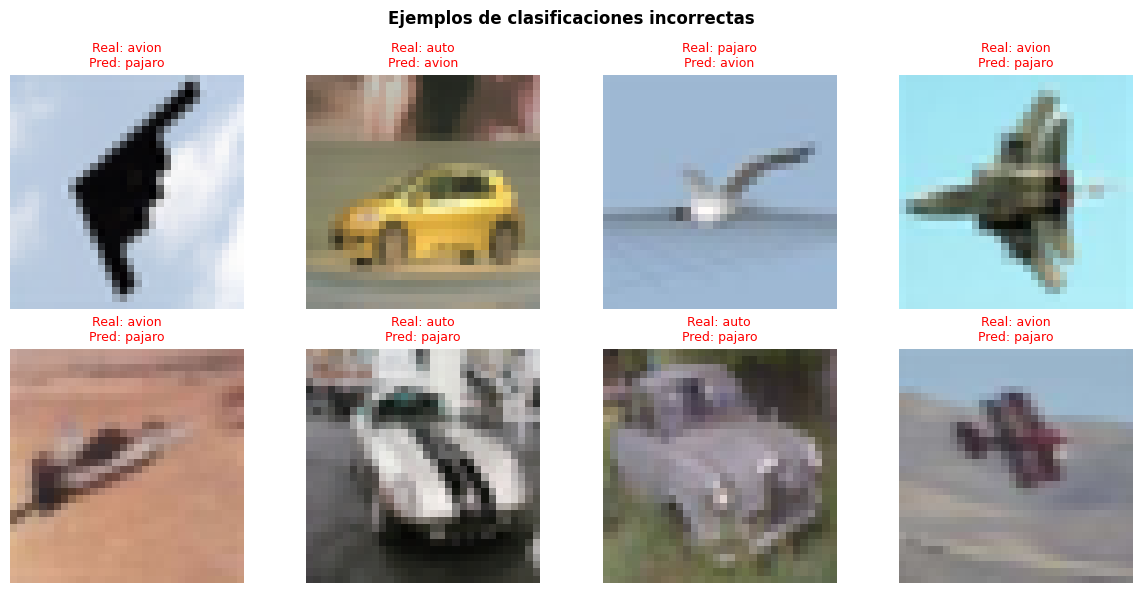

[Gráfica] Guardada como 'errores_clasificacion.png'


In [16]:
# =============================================================
# PASO 6B — ANÁLISIS DE ERRORES DE CLASIFICACIÓN
# =============================================================
# Mostramos imágenes que el modelo clasificó INCORRECTAMENTE.
# Esto nos ayuda a entender las limitaciones del modelo.

# Identificar índices de errores
idx_errores = np.where(y_pred != y_true)[0]

print(f"[Errores] Total en conjunto de prueba: {len(idx_errores)} / {len(y_true)}")
print(f"[Errores] Accuracy: {(1 - len(idx_errores)/len(y_true))*100:.1f}%")

if len(idx_errores) > 0:
    n_mostrar_err = min(8, len(idx_errores))
    seleccion_err = np.random.choice(idx_errores, n_mostrar_err, replace=False)

    fig, axes = plt.subplots(2, 4, figsize=(12, 6))
    fig.suptitle("Ejemplos de clasificaciones incorrectas",
                 fontsize=12, fontweight="bold")

    for ax, idx in zip(axes.flat, seleccion_err):
        ax.imshow(X_test[idx])
        real  = nombres_clases[y_true[idx]]
        pred  = nombres_clases[y_pred[idx]]
        ax.set_title(f"Real: {real}\nPred: {pred}",
                     fontsize=9, color="red")
        ax.axis("off")

    # Completar con ejes vacíos si hay menos de 8 errores
    for ax in list(axes.flat)[n_mostrar_err:]:
        ax.axis("off")

    plt.tight_layout()
    plt.savefig("errores_clasificacion.png", dpi=100, bbox_inches="tight")
    plt.show()
    print("[Gráfica] Guardada como 'errores_clasificacion.png'")
else:
    print("[Errores] ¡No hay errores en el conjunto de prueba!")

✅ Imagen cargada: avioncito.jpg


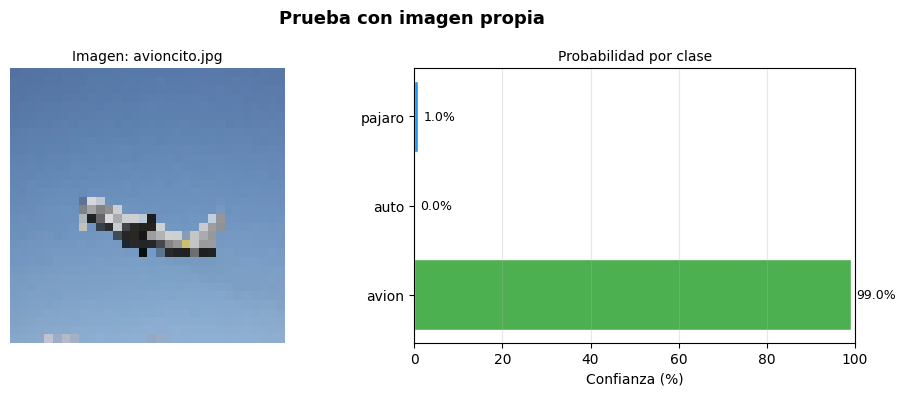

─────────────────────────────────────────────
  Clase predicha : AVION
  Confianza      : 99.0%
─────────────────────────────────────────────
  avion        ███████████████████  99.0% ◄
  auto                              0.0%
  pajaro                            1.0%
─────────────────────────────────────────────


In [ ]:
# ============================================================
# PASO 6C — PRUEBA CON IMAGEN PROPIA
# =============================================================
# Coloca tu imagen en la misma carpeta que este notebook y
# escribe su nombre en la variable IMAGEN_PRUEBA.

# ── ✏️ COMPLETAR — nombre de tu imagen ───────────────────────
IMAGEN_PRUEBA = "prueba_real.jpg"      # <-- cambia esto

# ── 1. Cargar y preprocesar ───────────────────────────────────
img_bgr = cv2.imread(IMAGEN_PRUEBA)

if img_bgr is None:
    print(f"❌ No se encontró '{IMAGEN_PRUEBA}'. Verifica el nombre y que esté en la misma carpeta.")
else:
    print(f"✅ Imagen cargada: {IMAGEN_PRUEBA}")

    img_resized = cv2.resize(img_bgr, (IMG_SIZE, IMG_SIZE))
    img_rgb     = cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB)
    img_norm    = img_rgb.astype("float32") / 255.0
    img_batch   = img_norm[np.newaxis]          # (1, 32, 32, 3)

    # ── 2. Predicción ─────────────────────────────────────────
    probs      = modelo.predict(img_batch, verbose=0)[0]
    idx_pred   = np.argmax(probs)
    clase_pred = nombres_clases[idx_pred]
    confianza  = probs[idx_pred]

    # ── 3. Visualización ──────────────────────────────────────
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
    fig.suptitle("Prueba con imagen propia", fontsize=13, fontweight="bold")

    ax1.imshow(img_rgb)
    ax1.set_title(f"Imagen: {IMAGEN_PRUEBA}", fontsize=10)
    ax1.axis("off")

    colores_barras = ["#2196F3" if i != idx_pred else "#4CAF50"
                      for i in range(N_CLASES)]
    barras = ax2.barh(nombres_clases, probs * 100,
                      color=colores_barras, edgecolor="white")
    ax2.set_xlim(0, 100)
    ax2.set_xlabel("Confianza (%)")
    ax2.set_title("Probabilidad por clase", fontsize=10)
    ax2.bar_label(barras, fmt="%.1f%%", padding=4, fontsize=9)
    ax2.grid(True, axis="x", alpha=0.3)

    plt.tight_layout()
    plt.savefig("prueba_imagen_propia.png", dpi=100, bbox_inches="tight")
    plt.show()

    print("─" * 45)
    print(f"  Clase predicha : {clase_pred.upper()}")
    print(f"  Confianza      : {confianza:.1%}")
    print("─" * 45)
    for i, (nombre, prob) in enumerate(zip(nombres_clases, probs)):
        barra = "█" * int(prob * 20)
        marca = " ◄" if i == idx_pred else ""
        print(f"  {nombre:<12} {barra:<20} {prob:.1%}{marca}")
    print("─" * 45)

### ✏️ COMPLETAR — Reflexión estructurada (mínimo ½ cuartilla)

---

#### 1. Desempeño del modelo de clasificación

**¿Qué clase(s) clasifica mejor? ¿Por qué crees que es así?**  
> *(Escribe aquí, mínimo 3 oraciones)*

**¿En qué clase(s) se observa más confusión? ¿A qué se puede deber?**  
> *(Escribe aquí, mínimo 3 oraciones)*

**¿Qué indican las métricas (accuracy, precisión, recall, F1)?**  
> *(Escribe aquí, mínimo 3 oraciones)*

---

#### 2. Comportamiento del rastreo

**¿Qué tan estable fue el ID de cada objeto a lo largo de la secuencia?**  
> *(Escribe aquí)*

**¿Qué problemas se presentaron (ID switching, oclusiones, detecciones falsas)?**  
> *(Escribe aquí)*

**¿Cómo se podría mejorar el tracker?**  
> *(Escribe aquí — menciona las alternativas documentadas en el código)*

---

#### 3. Conexión con los Temas 1 y 2

**Tema 1 — ¿Cómo influyó el preprocesamiento (resize, normalización) en el resultado?**  
> *(Escribe aquí)*

**Tema 2 — ¿Qué relación ves entre los filtros manuales (Sobel, Gauss) y los filtros aprendidos por la CNN?**  
> *(Escribe aquí — puedes hacer referencia a la imagen 'filtros_aprendidos.png')*

---

#### 4. Conclusión general

> *(Escribe un párrafo final integrando los tres temas del curso)*

---
## Paso 7 — Instrucciones para el Reporte Final

### Archivos a entregar en plataforma TecNM Virtual

| # | Archivo | Descripción |
|---|---------|-------------|
| 1 | `T3_A3_Clasificacion_Rastreo_ApellidoNombre.pdf` | Reporte técnico con toda la evidencia |
| 2 | `T3.A3.1_Clasificacion_Rastreo_RNC_ApellidoNombre.ipynb` | Este notebook con todas las celdas ejecutadas |

### Estructura del PDF (máx. 2 MB)

1. **Portada:** nombre, curso, tema, actividad.
2. **Descripción del problema y contexto** (Paso 1).
3. **Descripción del dataset** (tabla del Paso 3 + imagen `muestras_dataset.png`).
4. **Modelo de clasificación:**
   - Arquitectura usada (tabla del Paso 4).
   - Imágenes: `curvas_entrenamiento.png` + `matriz_confusion.png`.
5. **Módulo de rastreo:**
   - Explicación del método.
   - Imagen: `tracking_resultado.png`.
6. **Reflexión final** (Paso 6, celda ✏️ COMPLETAR).

### Checklist antes de entregar

- [ ] Todas las celdas del notebook tienen salida (ejecutadas de arriba a abajo).
- [ ] Las celdas `✏️ COMPLETAR` están rellenadas con tu información.
- [ ] Las 5 imágenes PNG están incluidas en el PDF.
- [ ] El nombre del archivo sigue la nomenclatura indicada.
- [ ] El PDF no supera 2 MB.
- [ ] El notebook se puede volver a ejecutar sin errores.

In [17]:
# =============================================================
# RESUMEN FINAL DE ARCHIVOS GENERADOS
# =============================================================

archivos_esperados = [
    "muestras_dataset.png",
    "curvas_entrenamiento.png",
    "matriz_confusion.png",
    "secuencia_preview.png",
    "tracking_resultado.png",
    "tracking_output.mp4",
    "filtros_aprendidos.png",
    "errores_clasificacion.png",
]

print("=" * 55)
print(" Resumen de archivos generados")
print("=" * 55)
for archivo in archivos_esperados:
    existe = os.path.isfile(archivo)
    estado = "✅" if existe else "❌ NO ENCONTRADO"
    print(f" {estado}  {archivo}")

print("=" * 55)
acc_final = accuracy_score(y_true, y_pred)
print(f" Accuracy final (prueba)  : {acc_final:.4f} ({acc_final*100:.1f}%)")
print(f" IDs de tracking asignados: {tracker.next_id}")
print("=" * 55)
print(" ¡Todos somos TecNM!")
print("=" * 55)

 Resumen de archivos generados
 ✅  muestras_dataset.png
 ✅  curvas_entrenamiento.png
 ✅  matriz_confusion.png
 ✅  secuencia_preview.png
 ✅  tracking_resultado.png
 ✅  tracking_output.mp4
 ✅  filtros_aprendidos.png
 ✅  errores_clasificacion.png
 Accuracy final (prueba)  : 0.9013 (90.1%)
 IDs de tracking asignados: 3
 ¡Todos somos TecNM!
